In [23]:
import pandas as pd

df = pd.read_csv('student_lifestyle_dataset.csv')

In [24]:
print("Primeras Filas")
display(df.head())

print("Información y NA")
df.info()

print("\n Estadistíca General")
df.describe()

Primeras Filas


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78


Información y NA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   Stress_Level                     2000 non-null   object 
 7   Gender                           2000 non-null   object 
 8   Grades                           2000 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 140.8+ KB

 Estadistíca General


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,7.789825
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.746777
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,5.600000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,7.250000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,7.780000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,8.320000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,10.000000


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

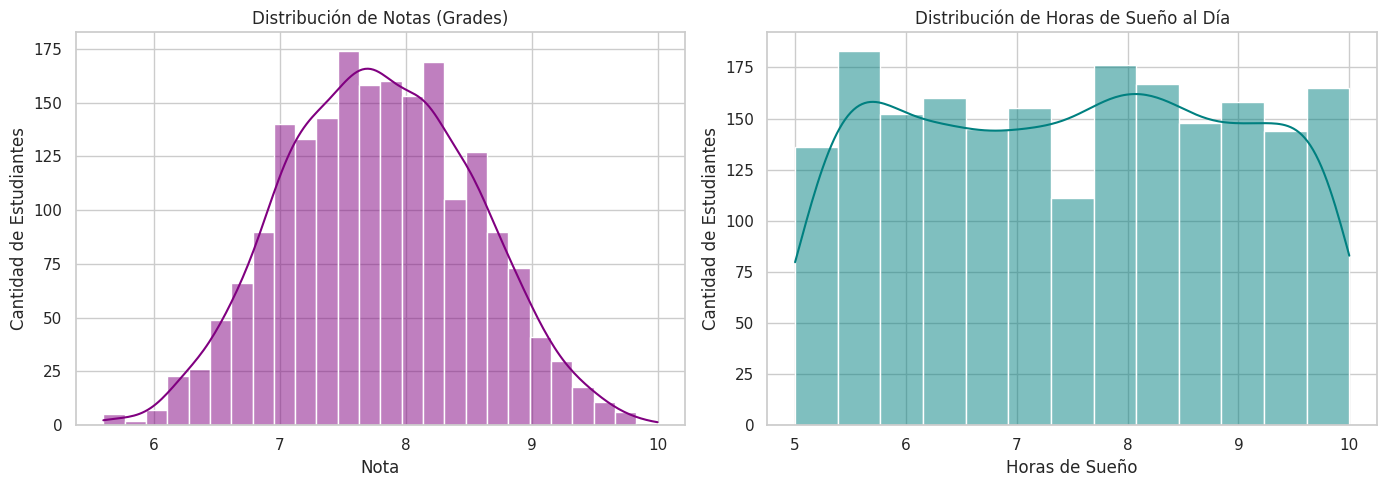

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Histogramas

# Gráfico 1: Distribución de Notas
sns.histplot(df['Grades'], kde=True, color='purple', ax=axes[0])
axes[0].set_title('Distribución de Notas (Grades)')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Cantidad de Estudiantes')

# Gráfico 2: Distribución de Horas de Sueño
sns.histplot(df['Sleep_Hours_Per_Day'], kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribución de Horas de Sueño al Día')
axes[1].set_xlabel('Horas de Sueño')
axes[1].set_ylabel('Cantidad de Estudiantes')

plt.tight_layout()
plt.savefig('graficadistri.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

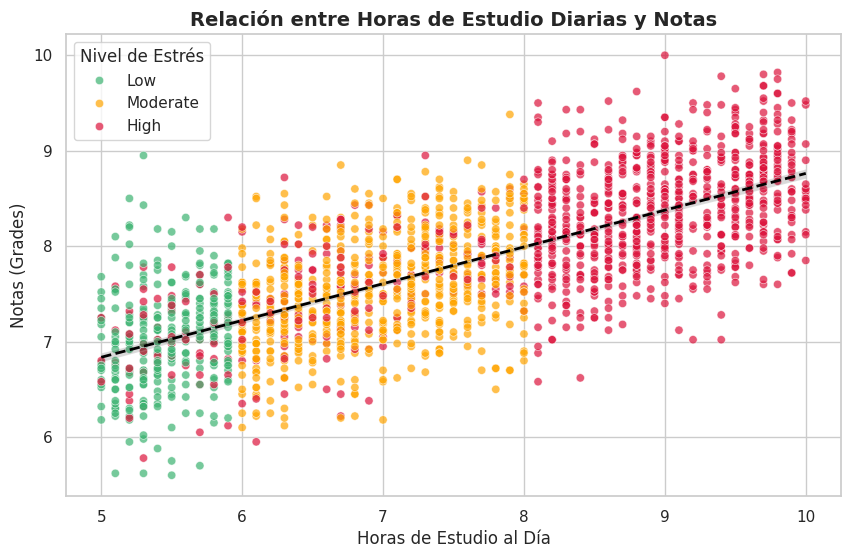

In [27]:
plt.figure(figsize=(10, 6))

# Dispersión de Horas de Estudio vs Notas con tendencia
sns.scatterplot(
    data=df,
    x='Study_Hours_Per_Day',
    y='Grades',
    hue='Stress_Level',
    hue_order=['Low', 'Moderate', 'High'],
    palette={'Low': 'mediumseagreen', 'Moderate': 'orange', 'High': 'crimson'},
    alpha=0.7
)

# Línea de tendencia general (Regresión lineal visual)
sns.regplot(
    data=df,
    x='Study_Hours_Per_Day',
    y='Grades',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'Tendencia general'}
)

plt.title('Relación entre Horas de Estudio Diarias y Notas', fontsize=14, fontweight='bold')
plt.xlabel('Horas de Estudio al Día')
plt.ylabel('Notas (Grades)')
plt.legend(title='Nivel de Estrés')
plt.savefig('graficad.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Selecciona variables de entrada (X) y objetivo (y)
features = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]

X = df[features]
y = df['Grades']

# División en conjunto de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creación y entrenamiento del modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- RESULTADOS DEL MODELO PREDICTIVO ---")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"RMSE (Error Cuadrático Medio): {rmse:.4f}\n")

# Ver el impacto de cada hábito (Coeficientes)
coef_df = pd.DataFrame({'Hábito / Variable': features, 'Impacto en la Nota (Coeficiente)': model.coef_})
display(coef_df.sort_values(by='Impacto en la Nota (Coeficiente)', ascending=False))

--- RESULTADOS DEL MODELO PREDICTIVO ---
R² (Coeficiente de Determinación): 0.5497
RMSE (Error Cuadrático Medio): 0.5128



,Hábito / Variable,Impacto en la Nota (Coeficiente)
0,Study_Hours_Per_Day,0.313970
3,Social_Hours_Per_Day,-0.068991
4,Physical_Activity_Hours_Per_Day,-0.070270
2,Sleep_Hours_Per_Day,-0.079009
1,Extracurricular_Hours_Per_Day,-0.095699


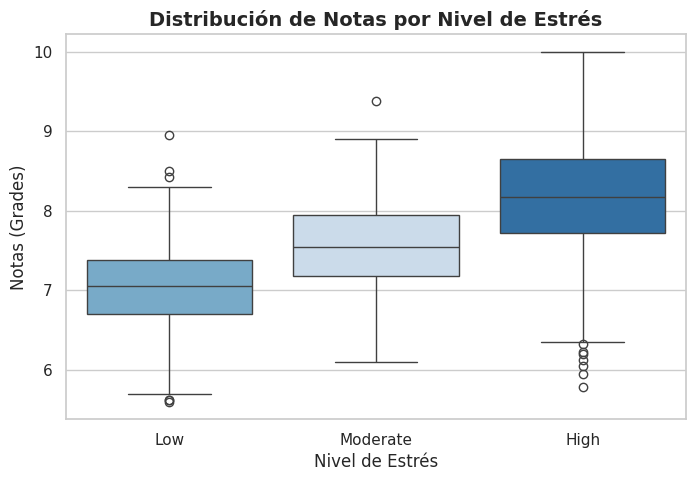

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Stress_Level',
    y='Grades',
    hue='Stress_Level', legend = False,
    order=['Low', 'Moderate', 'High'],
    palette='Blues'
)
plt.title('Distribución de Notas por Nivel de Estrés', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Estrés')
plt.ylabel('Notas (Grades)')
plt.savefig('grafica_estres_box.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()